In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import arabic_reshaper
from bidi.algorithm import get_display

# إعداد الستايل
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif' # تأكد من تثبيت مكتبة arabic-reshaper و python-bidi

In [6]:
# 1. تحميل الداتا
df = pd.read_csv('USA_Housing.csv')

# 2. حذف عمود العنوان (Address) لأنه نص، وحذف عمود السعر من الـ X
# تأكد إن كلمة 'Price' و 'Address' مكتوبين بنفس الحروف بالظبط عندك
X = df.drop(['Price', 'Address'], axis=1) 
y = df['Price']

# 3. تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ تم استبعاد النصوص وتقسيم البيانات بنجاح!")

✅ تم استبعاد النصوص وتقسيم البيانات بنجاح!


In [3]:
print(df.columns)

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')


In [7]:
# تدريب الموديل (استخدمنا RandomForest لأنه قوي في العقارات)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# التنبؤ
y_pred = model.predict(X_test)

# حساب المقاييس
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("-" * 30)
print(f"📊 دقة النموذج (R2 Score): {r2:.4f}")
print(f"📉 متوسط الخطأ (RMSE): {rmse:,.2f}")
print("-" * 30)

------------------------------
📊 دقة النموذج (R2 Score): 0.8824
📉 متوسط الخطأ (RMSE): 120,271.08
------------------------------


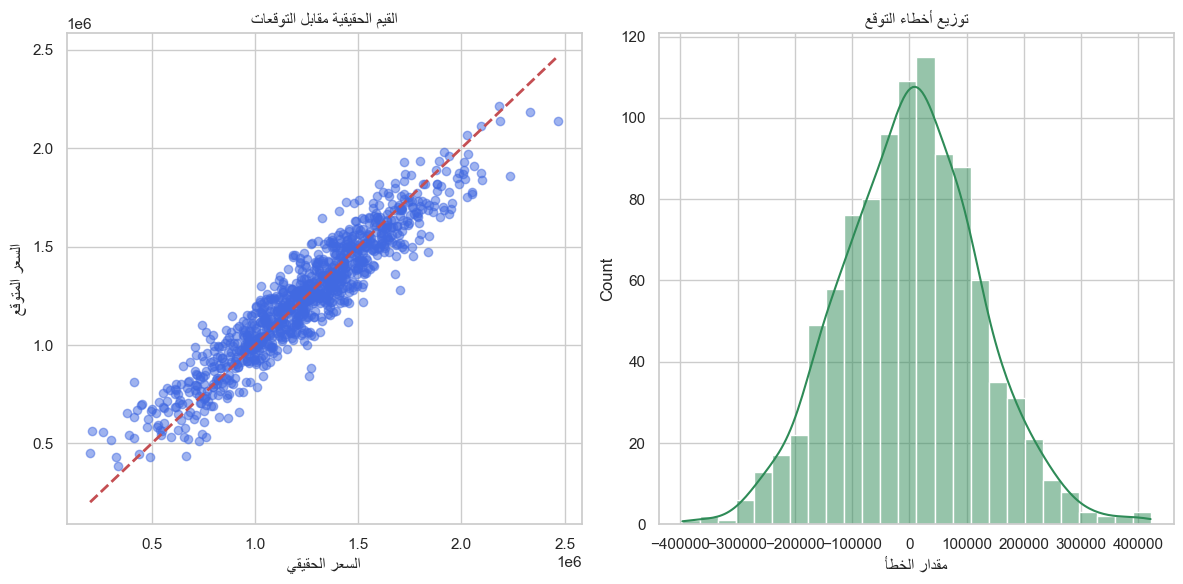

In [8]:
def get_arabic_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

plt.figure(figsize=(12, 6))

# 1. رسم القيم الحقيقية مقابل التوقعات
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title(get_arabic_text("القيم الحقيقية مقابل التوقعات"))
plt.xlabel(get_arabic_text("السعر الحقيقي"))
plt.ylabel(get_arabic_text("السعر المتوقع"))

# 2. رسم توزيع الأخطاء (Residuals)
plt.subplot(1, 2, 2)
sns.histplot(y_test - y_pred, kde=True, color='seagreen')
plt.title(get_arabic_text("توزيع أخطاء التوقع"))
plt.xlabel(get_arabic_text("مقدار الخطأ"))

plt.tight_layout()
plt.savefig('results_visualization.png') # حفظ الصورة لرفعها على GitHub
plt.show()